In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

df=pd.read_csv('../Project_description_and_data/claims_train.csv')
df['VehAge_1']=df['VehAge'] +1
df['VehAge_log']=np.log(df['VehAge_1'])
df['DrivAge_log']=np.log(df['DrivAge'])
df['Density_log']=np.log(df['Density'])
df['Exposure_adj'] = df['Exposure'].clip(upper=1.0)
df['VehGas']=np.where((df['VehGas']=='Regular'), 0, 1)

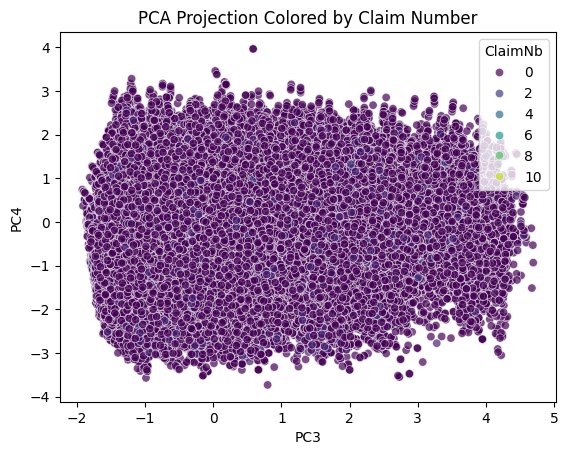

In [5]:
features = ['DrivAge_log', 'VehPower', 'VehAge_log', 'Density_log', 'BonusMalus']

X = df[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=5)
X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]
df["PC3"] = X_pca[:, 2]
df["PC4"] = X_pca[:, 3]
df["PC5"] = X_pca[:, 4]

sns.scatterplot(
    x="PC3",
    y="PC4",
    hue="ClaimNb",
    data=df,
    palette="viridis",
    alpha=0.7
)

plt.title("PCA Projection Colored by Claim Number")
plt.show()

In [6]:
explained = pca.explained_variance_ratio_
print(f"PC1: {explained[0]:.2%}, PC2: {explained[1]:.2%}, PC3: {explained[2]:.2%}, PC4: {explained[3]:.2%}, PC5: {explained[4]:.2%},  Total: {explained[:5].sum():.2%}")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5"],
    index=features
)
print(loadings)

PC1: 31.86%, PC2: 22.27%, PC3: 19.71%, PC4: 17.14%, PC5: 9.02%,  Total: 100.00%
                  PC1       PC2       PC3       PC4       PC5
DrivAge_log -0.672595  0.029320 -0.120935  0.242221  0.688084
VehPower    -0.144599  0.155265  0.975303 -0.046661  0.039880
VehAge_log   0.161456 -0.685714  0.167150  0.689276 -0.026223
Density_log  0.163178  0.708447 -0.051523  0.674598 -0.117212
BonusMalus   0.688485  0.054149  0.059708 -0.094698  0.714509


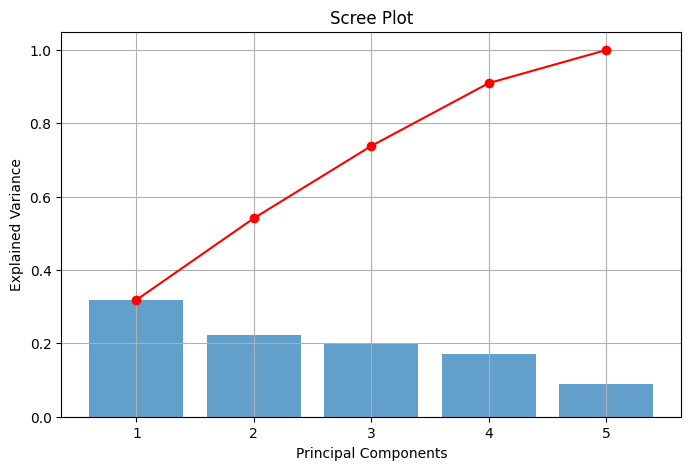

In [7]:
cumulative_variance=np.cumsum(explained)

plt.figure(figsize=(8,5))
plt.bar(range(1, len(explained)+1), explained, alpha=0.7, label='Individual Explained Variance')
plt.plot(range(1, len(explained)+1), cumulative_variance, marker='o', color='red', label='Cummulative Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Explained Variance')
plt.title('Scree Plot')
plt.grid()
plt.show()